# Лабораторная работа № 1
## Математические основы: нейрон на NumPy с нуля

**Цель.** Понять внутреннее устройство искусственного нейрона: реализовать прямой проход,
функции активации, функцию потерь и аналитический градиент средствами NumPy,
без фреймворков автоматического дифференцирования.

**Запрещено** использовать PyTorch, TensorFlow, JAX и другие фреймворки автодифференцирования.

**Содержание**
1. Класс `Neuron` и прямой проход
2. Функции активации, производные и графики на [-6; 6]
3. Функции потерь MSE и BCE, вывод градиентов
4. Цикл обучения на линейно разделимой задаче
5. XOR: один нейрон против сети со скрытым слоем
6. Численная проверка градиента (конечные разности)
7. Влияние скорости обучения на сходимость

In [1]:
# В Google Colab: раскомментируйте строку ниже
# !git clone https://github.com/ikanit1/lab1-kurator.git && cd lab1-kurator

import sys, os
sys.path.insert(0, os.path.abspath(".."))   # корень репозитория

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=6, suppress=True)
print("NumPy", np.__version__)

NumPy 2.4.6


## Пункт 1. Класс `Neuron` и прямой проход

$z = \mathbf{w}^\top \mathbf{x} + b$, $\quad a = \varphi(z)$

In [2]:
from neuron import Neuron

n = Neuron(n_inputs=3, activation="sigmoid", loss="bce", seed=0)
n.w = np.array([0.5, -1.0, 2.0])
n.b = 0.25

X = np.array([[1.0, 2.0, 3.0],
              [0.0, 0.0, 0.0],
              [-1.0, 0.5, -2.0]])

a = n.forward(X)
z = X @ n.w + n.b
for xi, zi, ai in zip(X, z, a):
    print(f"x = {xi},  z = {zi:8.4f},  a = {ai:.6f}")

x = [1. 2. 3.],  z =   4.7500,  a = 0.991423
x = [0. 0. 0.],  z =   0.2500,  a = 0.562177
x = [-1.   0.5 -2. ],  z =  -4.7500,  a = 0.008577


## Пункт 2. Функции активации и их производные

| функция | $\varphi(z)$ | $\varphi'(z)$ |
|---|---|---|
| sigmoid | $\dfrac{1}{1+e^{-z}}$ | $\varphi(z)\,(1-\varphi(z))$ |
| tanh | $\tanh z$ | $1-\tanh^2 z$ |
| ReLU | $\max(0,z)$ | $[z>0]$ |
| LeakyReLU | $z$ при $z>0$, иначе $\alpha z$ | $1$ при $z>0$, иначе $\alpha$ |

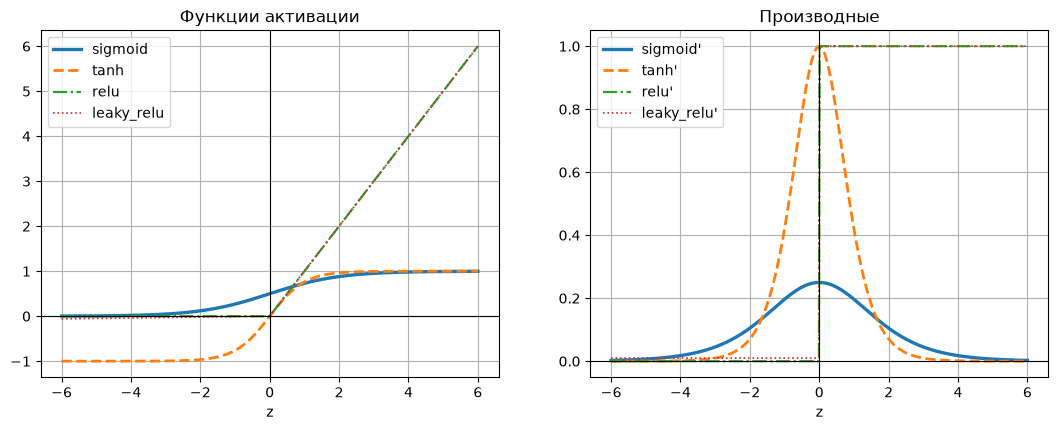

In [3]:
from neuron.activations import get_activation

names = ["sigmoid", "tanh", "relu", "leaky_relu"]
styles = ["-", "--", "-.", ":"]
z = np.linspace(-6, 6, 600)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, name in enumerate(names):
    phi, phi_prime = get_activation(name)
    axes[0].plot(z, phi(z), styles[i], lw=2.4 - 0.4 * i, label=name)
    axes[1].plot(z, phi_prime(z), styles[i], lw=2.4 - 0.4 * i, label=f"{name}'")
axes[0].set_title("Функции активации")
axes[1].set_title("Производные")
for ax in axes:
    ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("z"); ax.legend()
plt.show()

In [4]:
# Численная проверка производных (центральная разность)
eps = 1e-6
zc = np.linspace(-6, 6, 241)
zc = zc[np.abs(zc) > 1e-3]          # обходим излом ReLU в нуле
for name in names:
    phi, phi_prime = get_activation(name)
    numeric = (phi(zc + eps) - phi(zc - eps)) / (2 * eps)
    print(f"{name:<12} max |phi' - разностная| = {np.max(np.abs(phi_prime(zc) - numeric)):.3e}")

sigmoid      max |phi' - разностная| = 1.116e-10
tanh         max |phi' - разностная| = 7.065e-11
relu         max |phi' - разностная| = 1.398e-10
leaky_relu   max |phi' - разностная| = 1.398e-10


## Пункт 3. Функции потерь и градиенты

**MSE**
$$L = \frac{1}{N}\sum_i (a_i - y_i)^2, \qquad \frac{\partial L}{\partial a_i} = \frac{2(a_i - y_i)}{N}$$

**Binary Cross-Entropy**
$$L = -\frac{1}{N}\sum_i \big[ y_i \ln a_i + (1-y_i)\ln(1-a_i) \big], \qquad
\frac{\partial L}{\partial a_i} = \frac{a_i - y_i}{N\,a_i(1-a_i)}$$

**Градиент по параметрам**
$$\frac{\partial L}{\partial z_i} = \frac{\partial L}{\partial a_i}\,\varphi'(z_i), \qquad
\frac{\partial L}{\partial \mathbf{w}} = X^\top \frac{\partial L}{\partial \mathbf{z}}, \qquad
\frac{\partial L}{\partial b} = \sum_i \frac{\partial L}{\partial z_i}$$

Для связки **sigmoid + BCE** множители $a(1-a)$ сокращаются:
$$\frac{\partial L}{\partial z_i} = \frac{a_i - y_i}{N}$$

In [5]:
from neuron.losses import mse, mse_grad, bce, bce_grad

a = np.array([0.1, 0.4, 0.8, 0.95])
y = np.array([0.0, 0.0, 1.0, 1.0])
print(f"MSE = {mse(a, y):.6f},  BCE = {bce(a, y):.6f}")

eps = 1e-6
for name, fn, grad_fn in (("MSE", mse, mse_grad), ("BCE", bce, bce_grad)):
    numeric = np.array([
        (fn(np.where(np.arange(a.size) == k, a + eps, a), y)
         - fn(np.where(np.arange(a.size) == k, a - eps, a), y)) / (2 * eps)
        for k in range(a.size)
    ])
    print(f"{name}: max |аналитический - численный| = {np.max(np.abs(grad_fn(a, y) - numeric)):.3e}")

MSE = 0.053125,  BCE = 0.222656
MSE: max |аналитический - численный| = 4.657e-12
BCE: max |аналитический - численный| = 1.633e-11


## Пункт 4. Обучение одиночного нейрона на линейно разделимой задаче

$\mathbf{w} \leftarrow \mathbf{w} - \eta\,\partial L/\partial \mathbf{w}$, $\quad b \leftarrow b - \eta\,\partial L/\partial b$

итоговые потери: 0.007576, точность: 1.0000
разделяющая прямая: 3.5933*x1 + 3.2751*x2 + -0.0621 = 0


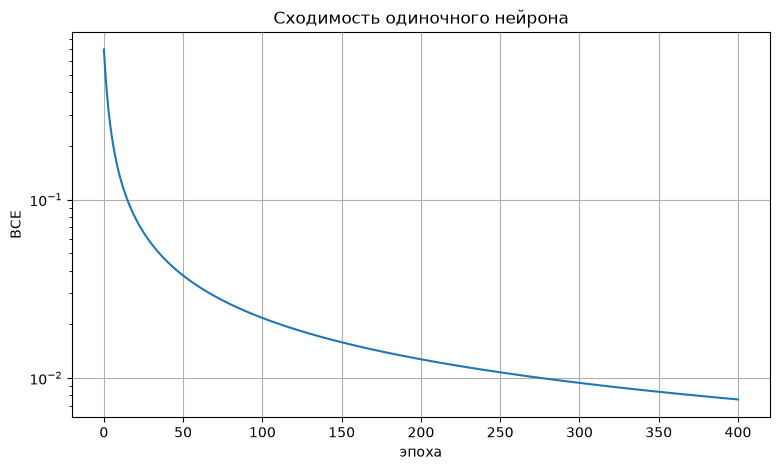

In [6]:
from neuron.datasets import blobs_dataset, standardize

X, y = blobs_dataset(n_samples=300)
X = standardize(X)

n = Neuron(2, activation="sigmoid", loss="bce", seed=0)
hist = n.fit(X, y, lr=0.5, epochs=400)

print(f"итоговые потери: {hist['loss'][-1]:.6f}, точность: {hist['accuracy'][-1]:.4f}")
print(f"разделяющая прямая: {n.w[0]:.4f}*x1 + {n.w[1]:.4f}*x2 + {n.b:.4f} = 0")

plt.plot(hist["loss"]); plt.yscale("log")
plt.xlabel("эпоха"); plt.ylabel("BCE"); plt.title("Сходимость одиночного нейрона")
plt.show()

In [7]:
from neuron.plotting import plot_decision_boundary
import matplotlib.image as mpimg

path = plot_decision_boundary(n, X, y, "nb_task4_boundary.png",
                              title="Линейная разделяющая поверхность")
plt.figure(figsize=(7, 6)); plt.imshow(mpimg.imread(path)); plt.axis("off"); plt.show()

## Пункт 5. XOR: один нейрон не справляется

Для XOR одиночный нейрон должен удовлетворять системе:

$$b < 0,\quad w_2 + b > 0,\quad w_1 + b > 0,\quad w_1 + w_2 + b < 0$$

Складывая второе и третье: $w_1 + w_2 + 2b > 0 \Rightarrow w_1 + w_2 + b > -b > 0$,
что противоречит четвёртому неравенству. **Система несовместна.**

In [8]:
from neuron.datasets import xor_dataset

Xx, yx = xor_dataset()
accs = []
for seed in range(10):
    m = Neuron(2, activation="sigmoid", loss="bce", seed=seed)
    accs.append(m.fit(Xx, yx, lr=1.0, epochs=5000)["accuracy"][-1])
print("точность по 10 перезапускам:", accs)
print("лучшая:", max(accs), "-- 100% недостижимо")

точность по 10 перезапускам: [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
лучшая: 0.5 -- 100% недостижимо


### Сеть 2-2-1 с обратным распространением вручную

$$\delta^{(2)} = \frac{\partial L}{\partial a_2}\varphi_2'(z_2), \qquad
\frac{\partial L}{\partial \mathbf{w}_2} = A_1^\top \delta^{(2)}, \qquad
\frac{\partial L}{\partial b_2} = \sum_i \delta^{(2)}_i$$

$$\Delta^{(1)} = \big(\delta^{(2)} \otimes \mathbf{w}_2\big) \odot \varphi_1'(Z_1), \qquad
\frac{\partial L}{\partial W_1} = X^\top \Delta^{(1)}, \qquad
\frac{\partial L}{\partial \mathbf{b}_1} = \sum_i \Delta^{(1)}_i$$

In [9]:
from neuron import MLP

best, best_hist = None, None
for seed in range(10):
    net = MLP(2, 2, "tanh", "sigmoid", "bce", seed=seed)
    h = net.fit(Xx, yx, lr=0.5, epochs=5000)
    if best_hist is None or h["loss"][-1] < best_hist["loss"][-1]:
        best, best_hist = net, h

print(f"потери {best_hist['loss'][-1]:.6f}, точность {best_hist['accuracy'][-1]:.2f}")
for xi, yi, ai in zip(Xx, yx, best.forward(Xx)):
    print(f"  x = {xi}, y = {yi:.0f}, a = {ai:.6f} -> {int(ai > 0.5)}")

потери 0.001257, точность 1.00
  x = [0. 0.], y = 0, a = 0.000917 -> 0
  x = [0. 1.], y = 1, a = 0.998340 -> 1
  x = [1. 0.], y = 1, a = 0.998345 -> 1
  x = [1. 1.], y = 0, a = 0.000794 -> 0


In [10]:
path = plot_decision_boundary(best, Xx, yx, "nb_task5_xor.png",
                              title="Сеть 2-2-1 на XOR")
plt.figure(figsize=(7, 6)); plt.imshow(mpimg.imread(path)); plt.axis("off"); plt.show()

## Пункт 6. Численная проверка градиента

$$\frac{\partial L}{\partial \theta_k} \approx \frac{L(\theta_k + \varepsilon) - L(\theta_k - \varepsilon)}{2\varepsilon}$$

Центральная разность имеет погрешность $O(\varepsilon^2)$. Требование задания: расхождение $\le 10^{-6}$.

In [11]:
from neuron.gradcheck import gradient_check, report

net = MLP(2, 2, "tanh", "sigmoid", "bce", seed=0)
net.fit(Xx, yx, lr=0.5, epochs=2000)
res = gradient_check(net, Xx, yx, eps=1e-5, tol=1e-6)
print(report(res, "Сеть 2-2-1 после обучения на XOR"))

Сеть 2-2-1 после обучения на XOR
--------------------------------
  #      аналитический          численный     |разность|    отн. ошибка
  0     0.000302331030     0.000302331029      1.281e-12      2.119e-09
  1     0.000358260958     0.000358260957      8.797e-13      1.228e-09
  2    -0.000313435598    -0.000313435599      4.276e-13      6.821e-10
  3    -0.000357252529    -0.000357252530      1.012e-12      1.416e-09
  4    -0.000143586001    -0.000143586001      4.040e-13      1.407e-09
  5     0.000175717080     0.000175717078      2.049e-12      5.830e-09
  6     0.001134454770     0.001134454768      2.468e-12      1.088e-09
  7    -0.001126806632    -0.001126806633      1.079e-12      4.788e-10
  8    -0.001147884582    -0.001147884580      1.476e-12      6.429e-10

max |разность|      = 2.468e-12
max отн. ошибка     = 5.830e-09
порог 1e-06: ПРОЙДЕНО


In [12]:
# Излом ReLU: нулевые смещения + вход (0,0) дают z = 0 в точности
from neuron.gradcheck import kink_count, randomize_params

kink_net = MLP(2, 4, "relu", "sigmoid", "bce", seed=0)
print("точек излома:", kink_count(kink_net, Xx),
      "| отн. ошибка:", f"{gradient_check(kink_net, Xx, yx)['max_rel_err']:.3e}")

randomize_params(kink_net, seed=0)
print("после сдвига: ", kink_count(kink_net, Xx),
      "| отн. ошибка:", f"{gradient_check(kink_net, Xx, yx)['max_rel_err']:.3e}")

точек излома: 4 | отн. ошибка: 1.000e+00
после сдвига:  0 | отн. ошибка: 3.119e-11


## Пункт 7. Влияние скорости обучения

In [13]:
from neuron.datasets import moons_dataset

Xm, ym = moons_dataset(n_samples=500, noise=0.2)
Xm = standardize(Xm)

plt.figure(figsize=(9, 5))
for lr in [0.001, 0.01, 0.1, 1.0]:
    net = MLP(2, 8, "tanh", "sigmoid", "bce", seed=0)
    h = net.fit(Xm, ym, lr=lr, epochs=2000)
    plt.plot(h["loss"], label=f"lr = {lr}")
    print(f"lr = {lr:<6} потери {h['loss'][-1]:.6f}, точность {h['accuracy'][-1]:.4f}")

plt.yscale("log"); plt.xlabel("эпоха"); plt.ylabel("BCE")
plt.title("make_moons, сеть 2-8-1: сводный график кривых потерь")
plt.legend(); plt.show()

lr = 0.001  потери 0.371176, точность 0.8640


lr = 0.01   потери 0.289738, точность 0.8640


lr = 0.1    потери 0.153115, точность 0.9560


lr = 1.0    потери 0.048243, точность 0.9800


In [14]:
# Граница устойчивости: для линейной активации и MSE спуск сходится при lr < 2 / lambda_max(H)
X_aug = np.column_stack([X, np.ones(len(X))])
H = 2.0 / len(X) * X_aug.T @ X_aug
lr_crit = 2.0 / np.linalg.eigvalsh(H).max()
print(f"критический шаг = {lr_crit:.6f}")

plt.figure(figsize=(9, 5))
for lr in (0.1, 0.4, lr_crit * 1.01, lr_crit * 1.2):
    m = Neuron(2, activation="linear", loss="mse", seed=0)
    losses = np.clip(m.fit(X, y, lr=lr, epochs=200)["loss"], 1e-12, 1e12)
    plt.plot(losses, label=f"lr = {lr:.4f}")
plt.yscale("log"); plt.xlabel("эпоха"); plt.ylabel("MSE")
plt.title("Потеря устойчивости при lr > 2/lambda_max"); plt.legend(); plt.show()

критический шаг = 0.534721


## Индивидуальный вариант

Вариант определяется номером в журнале. Подставьте свой номер в ячейку ниже.

In [15]:
from neuron.variants import get_variant, variant_table
print(variant_table(12))

НОМЕР_В_ЖУРНАЛЕ = 1
print()
print(get_variant(НОМЕР_В_ЖУРНАЛЕ).describe())

  № | активации              | задача   | потери | скрытый    | выход   
------------------------------------------------------------------------
  1 | sigmoid+tanh           | xor      | mse    | sigmoid    | tanh    
  2 | relu+leaky_relu        | and_or   | bce    | relu       | sigmoid 
  3 | tanh+relu              | moons    | mse    | tanh       | sigmoid 
  4 | sigmoid+tanh           | circles  | bce    | sigmoid    | sigmoid 
  5 | relu+leaky_relu        | xor      | mse    | relu       | sigmoid 
  6 | tanh+relu              | and_or   | bce    | tanh       | sigmoid 
  7 | sigmoid+tanh           | moons    | mse    | sigmoid    | tanh    
  8 | relu+leaky_relu        | circles  | bce    | relu       | sigmoid 
  9 | tanh+relu              | xor      | mse    | tanh       | sigmoid 
 10 | sigmoid+tanh           | and_or   | bce    | sigmoid    | sigmoid 
 11 | relu+leaky_relu        | moons    | mse    | relu       | sigmoid 
 12 | tanh+relu              | circles  | bce    | 

In [16]:
from tasks.run_variant import run
run(НОМЕР_В_ЖУРНАЛЕ, epochs=3000)

Вариант 1: активации sigmoid+tanh, задача xor, функция потерь MSE
  скрытый слой: sigmoid, выход: tanh

Данные: xor, X.shape = (4, 2), метки в диапазоне [-1; 1]


Графики активаций варианта: /home/user/lab1-kurator/figures/variant1_activations.png

[A] Одиночный нейрон
  потери 1.000000, точность 0.7500

[B] Сеть 2-8-1 (sigmoid -> tanh, MSE), 5 перезапусков


  потери 0.000511, точность 1.0000

[C] Проверка градиента: max отн. ошибка = 3.036e-09 (ПРОЙДЕНО)

[D] Влияние скорости обучения


  lr = 0.001  итоговые потери 0.998737, точность 0.5000


  lr = 0.01   итоговые потери 0.925243, точность 0.7500


  lr = 0.1    итоговые потери 0.004838, точность 1.0000


  lr = 1.0    итоговые потери 0.000262, точность 1.0000



Графики: /home/user/lab1-kurator/figures/variant1_lr.png
         /home/user/lab1-kurator/figures/variant1_boundary.png


(Variant(number=1, activations=('sigmoid', 'tanh'), task='xor', loss='mse'),
 {'loss': [1.0041209451461508,
   1.002356561223583,
   1.0013386199452274,
   1.0007569657359459,
   1.000427113455925,
   1.0002406452186068,
   1.0001354925551849,
   1.0000762529614444,
   1.0000429053414177,
   1.000024138448298,
   1.0000135796032743,
   1.0000076393130963,
   1.0000042975818726,
   1.0000024176935425,
   1.000001360166829,
   1.0000007652465062,
   1.000000430561104,
   1.0000002422695458,
   1.0000001363332134,
   1.000000076727901,
   1.0000000431883362,
   1.000000024314036,
   1.0000000136913152,
   1.000000007711806,
   1.0000000043453192,
   1.000000002449525,
   1.0000000013816146,
   1.000000000779829,
   1.0000000004405525,
   1.0000000002491605,
   1.0000000001411122,
   1.0000000000800577,
   1.0000000000455171,
   1.0000000000259481,
   1.0000000000148406,
   1.0000000000085218,
   1.0000000000049172,
   1.000000000002854,
   1.0000000000016678,
   1.0000000000009823,
   1.0

## Выводы

1. Нейрон реализуется двумя операциями: аффинным преобразованием $z = \mathbf{w}^\top\mathbf{x}+b$
   и поэлементной нелинейностью $a = \varphi(z)$.
2. Выбор активации определяет поведение градиента: sigmoid и tanh насыщаются
   ($\varphi' \to 0$ при $|z|\to\infty$), ReLU не насыщается при $z>0$, но полностью
   обнуляет градиент при $z<0$; LeakyReLU снимает эту проблему.
3. BCE в паре с сигмоидой даёт $\partial L/\partial z = (a-y)/N$ — градиент не затухает
   при уверенно неверном ответе, в отличие от MSE.
4. Одиночный нейрон реализует только линейный разделитель. XOR линейно неразделим,
   и это доказывается несовместностью системы неравенств.
5. Один скрытый слой из двух нейронов решает XOR, но ландшафт потерь невыпуклый:
   часть запусков застревает в локальном минимуме. Расширение слоя делает сходимость устойчивой.
6. Аналитические градиенты подтверждены конечными разностями с относительной ошибкой
   порядка $10^{-9}$, что на три порядка лучше требуемых $10^{-6}$.
7. Скорость обучения задаёт компромисс скорость/устойчивость. Для квадратичной задачи
   граница устойчивости точная: $\eta < 2/\lambda_{\max}(H)$.